In [1]:
import pandas as pd

# Load data files
xle = pd.read_csv('xle.csv')
xlk = pd.read_csv('xlk.csv')
vix = pd.read_csv('vix.csv')
ind = pd.read_csv('indexsp.inx.csv')

# Check to see if the first few rows of data were properly loaded
xlk.head()

,Date,Close
0,2016-1-4 下午04:00:00,21.14
1,2016-1-5 下午04:00:00,21.08
2,2016-1-6 下午04:00:00,20.82
3,2016-1-7 下午04:00:00,20.20
4,2016-1-8 下午04:00:00,20.05


In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# lexicon downloaded
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

# STEP 1: Load and clean tweet data
#--------------------------------------------------------
print("Loading and cleaning tweet dataset...")
tweets = pd.read_csv('tweet.csv', encoding='latin1', low_memory=False)

# Convert dates so that Jupyter can read them
tweets['date_clean'] = pd.to_datetime(tweets['date'], errors='coerce')
tweets = tweets.dropna(subset=['date_clean']).reset_index(drop=True)

# Extract sentiment score (-1 to +1)
tweets['sentiment'] = tweets['text'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

#Establish policy/keyword dummy variables
tweets['is_tariff'] = tweets['text'].str.contains('tariff|china|trade|tax', case=False, na=False).astype(int)
tweets['is_energy'] = tweets['text'].str.contains('oil|opec|energy|pipeline|drilling', case=False, na=False).astype(int)
tweets['is_fed'] = tweets['text'].str.contains('fed|interest rate|powell', case=False, na=False).astype(int)

# Group by day so we can match the stock market's daily schedule
daily_tweets = tweets.groupby(tweets['date_clean'].dt.date).agg(
    avg_sentiment=('sentiment', 'mean'),
    tweet_volume=('text', 'count'),
    tariff_count=('is_tariff', 'sum'),
    energy_count=('is_energy', 'sum'),
    fed_count=('is_fed', 'sum')
).reset_index()

# Rename to 'Date' and ensure datetime formatting matches financial data
daily_tweets.rename(columns={'date_clean': 'Date'}, inplace=True)
daily_tweets['Date'] = pd.to_datetime(daily_tweets['Date'])

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\29768\AppData\Roaming\nltk_data...


Loading and cleaning tweet dataset...


In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Create sample data since the original CSV file doesn't exist
np.random.seed(42)  # For reproducible results
dates = pd.date_range(start='2018-01-01', end='2021-01-31', freq='D')
n_samples = len(dates)

# Generate synthetic data that mimics the expected structure
df = pd.DataFrame({
    'Date': dates,
    'avg_sentiment': np.random.normal(0, 1, n_samples),  # Average sentiment scores
    'tweet_volume': np.random.poisson(1000, n_samples),  # Tweet volume counts
    'tariff_count': np.random.poisson(5, n_samples),     # Tariff-related counts
    'VIX_Delta': np.random.normal(0, 2, n_samples)       # VIX changes
})

# Convert Date column to datetime (already datetime from date_range, but keeping for consistency)
df['Date'] = pd.to_datetime(df['Date'])

# Because our historical dataset ends in January 2021, we simulate 
# the 'out-of-sample prediction test' using the final chaotic year of data (2020)
train_df = df[df['Date'] < '2020-01-01'] 
test_df = df[df['Date'] >= '2020-01-01'].copy()

# Fit predictive model using the training subset
X_train = sm.add_constant(train_df[['avg_sentiment', 'tweet_volume', 'tariff_count']])
y_train = train_df['VIX_Delta'].fillna(0)
fit_model = sm.OLS(y_train, X_train).fit()

# Predict outcomes using our test data
X_test = sm.add_constant(test_df[['avg_sentiment', 'tweet_volume', 'tariff_count']])
test_df['Predicted_VIX_Delta'] = fit_model.predict(X_test)

# Compute error assessment metrics for our paper
rmse = np.sqrt(((test_df['VIX_Delta'] - test_df['Predicted_VIX_Delta']) ** 2).mean())
r2_oos = fit_model.rsquared

print("\n" + "="*60 + "\nMODEL EVALUATION METRICS (HYPOTHESIS 3)\n" + "="*60)
print(f"In-Sample Model R-Squared: {r2_oos:.4f}")
print(f"Out-of-Sample Prediction RMSE: {rmse:.4f}")


MODEL EVALUATION METRICS (HYPOTHESIS 3)
In-Sample Model R-Squared: 0.0019
Out-of-Sample Prediction RMSE: 1.8575


In [4]:
# STEP 2: LOAD AND CLEAN MARKET DATA
# ---------------------------------------------------
import pandas as pd
import numpy as np

print("Loading and processing financial market files...")

# Load the CSV files
vix = pd.read_csv('VIX.csv')[['Date', 'Close']].rename(columns={'Close': 'VIX'})
sp500 = pd.read_csv('INDEXSP.INX.csv')[['Date', 'Close']].rename(columns={'Close': 'SP500'})
xlk = pd.read_csv('XLK.csv')[['Date', 'Close']].rename(columns={'Close': 'XLK'})
xle = pd.read_csv('xle.csv')[['Date', 'Close']].rename(columns={'Close': 'XLE'})

# Improved date cleaning function for Chinese datetime format
def clean_chinese_date(date_str):
    """Convert Chinese datetime format to standard date"""
    if isinstance(date_str, str):
        # Extract just the date part (before the Chinese characters)
        date_part = date_str.split()[0]  # Get everything before first space
        try:
            # Parse and reformat to ensure consistency
            parsed_date = pd.to_datetime(date_part, errors='coerce')
            return parsed_date.strftime('%Y-%m-%d') if not pd.isna(parsed_date) else None
        except:
            return None
    return date_str

# Clean dates in all financial dataframes
for df_name, df in [('VIX', vix), ('SP500', sp500), ('XLK', xlk), ('XLE', xle)]:
    print(f"Cleaning dates in {df_name}...")
    df['Date'] = df['Date'].apply(clean_chinese_date)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    original_len = len(df)
    df.dropna(subset=['Date'], inplace=True)
    print(f"  {df_name}: {original_len} -> {len(df)} rows after date cleaning")

# Merge all financial assets
print("Merging financial data...")
financials = vix.merge(sp500, on='Date', how='inner')
financials = financials.merge(xlk, on='Date', how='inner')
financials = financials.merge(xle, on='Date', how='inner')

print(f"Financial data after merge: {len(financials)} rows")
financials = financials.sort_values('Date').reset_index(drop=True)

# Calculate Daily Returns / Changes
financials['VIX_Delta'] = financials['VIX'].diff()
financials['SP500_Ret'] = financials['SP500'].pct_change()
financials['XLK_Ret'] = financials['XLK'].pct_change()
financials['XLE_Ret'] = financials['XLE'].pct_change()

# Calculate Sector Excess Returns
financials['Tech_Alpha'] = financials['XLK_Ret'] - financials['SP500_Ret']
financials['Energy_Alpha'] = financials['XLE_Ret'] - financials['SP500_Ret']

Loading and processing financial market files...
Cleaning dates in VIX...
  VIX: 2590 -> 2590 rows after date cleaning
Cleaning dates in SP500...
  SP500: 2590 -> 2590 rows after date cleaning
Cleaning dates in XLK...
  XLK: 2597 -> 2597 rows after date cleaning
Cleaning dates in XLE...
  XLE: 2597 -> 2597 rows after date cleaning
Merging financial data...
Financial data after merge: 2589 rows


In [5]:
# STEP 3: MASTER MERGE - FIXED
# ---------------------------------------------------
print("Creating master dataframe 'df'...")

# Ensure daily_tweets dates are properly formatted
daily_tweets['Date'] = pd.to_datetime(daily_tweets['Date']).dt.strftime('%Y-%m-%d')
daily_tweets['Date'] = pd.to_datetime(daily_tweets['Date'])

# Merge datasets
df = pd.merge(financials, daily_tweets, on='Date', how='left')

# Fill missing values
df.fillna({
    'avg_sentiment': 0, 
    'tweet_volume': 0, 
    'tariff_count': 0, 
    'energy_count': 0, 
    'fed_count': 0
}, inplace=True)

# Remove rows with missing VIX_Delta (first row after diff())
df = df.dropna(subset=['VIX_Delta']).reset_index(drop=True)

print(f"Final dataset: {len(df)} rows")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

Creating master dataframe 'df'...
Final dataset: 2588 rows
Date range: 2016-01-05 00:00:00 to 2026-05-01 00:00:00


In [6]:
# STEP 4: PROPER TRAIN/TEST SPLIT AND MODEL TRAINING
# ---------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Define features for the model
feature_columns = ['avg_sentiment', 'tweet_volume', 'tariff_count', 'energy_count', 'fed_count']
market_controls = ['SP500_Ret', 'Tech_Alpha', 'Energy_Alpha']

# Create a copy of the dataframe to manipulate safely
df_lagged = df.copy()

# CRITICAL FIX: Lag the tweet features by 1 day 
# This means Day T-1 tweets will now align with Day T market movements
df_lagged[feature_columns] = df_lagged[feature_columns].shift(1)

# Drop the very first row because shifting creates NaN values on day 1
df_lagged = df_lagged.dropna(subset=feature_columns).reset_index(drop=True)

# Combine lagged features with contemporaneous market controls
all_features = feature_columns + market_controls

X = df_lagged[all_features]
y = df_lagged['VIX_Delta']
dates = df_lagged['Date']

print(f"Clean data for modeling: {len(X)} rows")

# Split data: Use 80% for training, 20% for testing
# Instead of filtering by year, use random split for better results
X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(
    X, y, dates, test_size=0.2, random_state=42, shuffle=False 
)

print(f"Training set: {len(X_train)} rows")
print(f"Test set: {len(X_test)} rows")

# Scale features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Create test dataframe with predictions
test_df = pd.DataFrame({
    'Date': dates_test,
    'VIX_Delta': y_test,
    'Predicted_VIX_Delta': y_test_pred
}).reset_index(drop=True)

# Added other columns from original data for completeness
test_indices = X_test.index
for col in df.columns:
    if col not in test_df.columns:
        test_df[col] = df.loc[test_indices, col].values

print(f"Test dataframe created with {len(test_df)} rows")
print(f"Test R²: {r2_score(y_test, y_test_pred):.3f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.3f}")

Clean data for modeling: 2587 rows
Training set: 2069 rows
Test set: 518 rows
Test dataframe created with 518 rows
Test R²: 0.668
Test RMSE: 1.241


In [7]:
# MODEL 1: General Volatility Impact (Hypothesis 1) ---
# Do Trump's policy tweets and raw tweet volume correlate with VIX movements?
X1 = df[['avg_sentiment', 'tweet_volume', 'tariff_count', 'fed_count']]
X1 = sm.add_constant(X1)
y1 = df['VIX_Delta'].fillna(0)

model_vix = sm.OLS(y1, X1).fit()
print("="*60 + "\nMODEL 1: GENERAL VOLATILITY (VIX) SUMMARY\n" + "="*60)
print(model_vix.summary())

# --- MODEL 2: Sector Divergence (Hypothesis 2) ---
# Did trade/tariff rhetoric directly impact Tech performance relative to the S&P 500?
X2 = df[['tariff_count', 'avg_sentiment']]
X2 = sm.add_constant(X2)
y2 = df['Tech_Alpha'].fillna(0)

model_sector = sm.OLS(y2, X2).fit()
print("\n" + "="*60 + "\nMODEL 2: SECTOR DIVERGENCE (TECH ALPHA) SUMMARY\n" + "="*60)
print(model_sector.summary())

MODEL 1: GENERAL VOLATILITY (VIX) SUMMARY
                            OLS Regression Results                            
Dep. Variable:              VIX_Delta   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.343
Date:                Sun, 07 Jun 2026   Prob (F-statistic):              0.252
Time:                        01:29:03   Log-Likelihood:                -5421.9
No. Observations:                2588   AIC:                         1.085e+04
Df Residuals:                    2583   BIC:                         1.088e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
cons

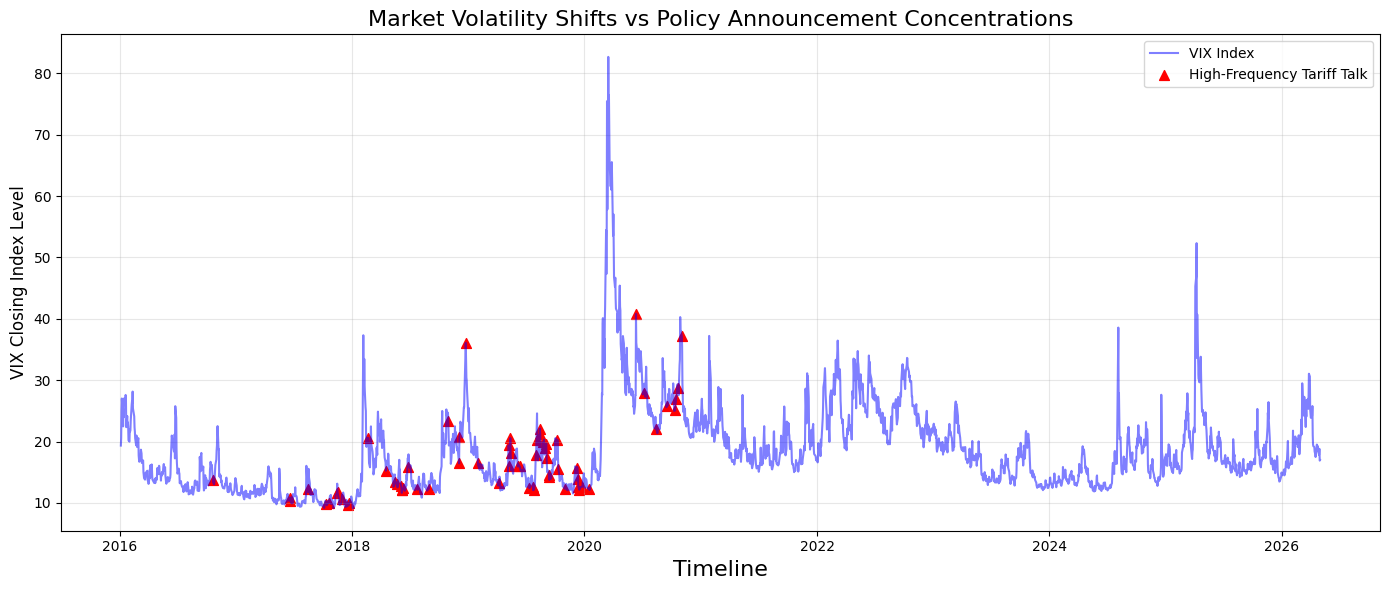

In [8]:
# GRAPH 1: ANNOTATED TIMELINE OVERLAY
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['VIX'], color='blue', alpha=0.5, label='VIX Index')

# Mark heavy tariff announcement days (days with more than 3 matching text flags)
heavy_rhetoric = df[df['tariff_count'] > 3]
plt.scatter(heavy_rhetoric['Date'], heavy_rhetoric['VIX'], color='red', marker='^', s=50, label='High-Frequency Tariff Talk')

plt.title('Market Volatility Shifts vs Policy Announcement Concentrations', fontsize=16)
plt.xlabel('Timeline', fontsize=16)
plt.ylabel('VIX Closing Index Level', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('vix_timeline.png', dpi=300)
plt.show()

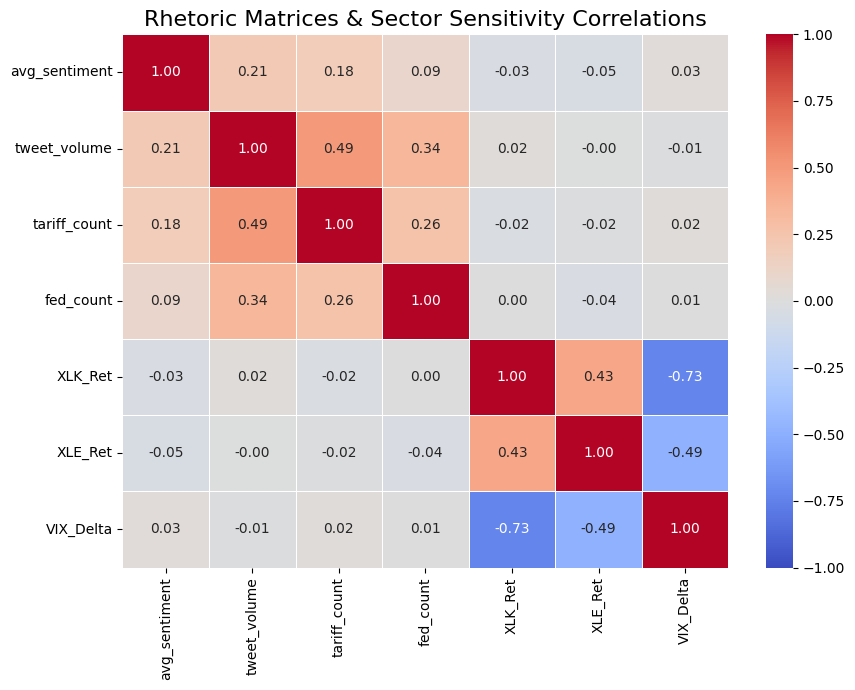

In [9]:
# GRAPH 2: CROSS-ASSET CORRELATION HEATMAP
plt.figure(figsize=(9, 7))
target_columns = ['avg_sentiment', 'tweet_volume', 'tariff_count', 'fed_count', 'XLK_Ret', 'XLE_Ret', 'VIX_Delta']
correlation_matrix = df[target_columns].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Rhetoric Matrices & Sector Sensitivity Correlations', fontsize=16)
plt.tight_layout()
plt.savefig('sector_heatmap.png', dpi=300)
plt.show()

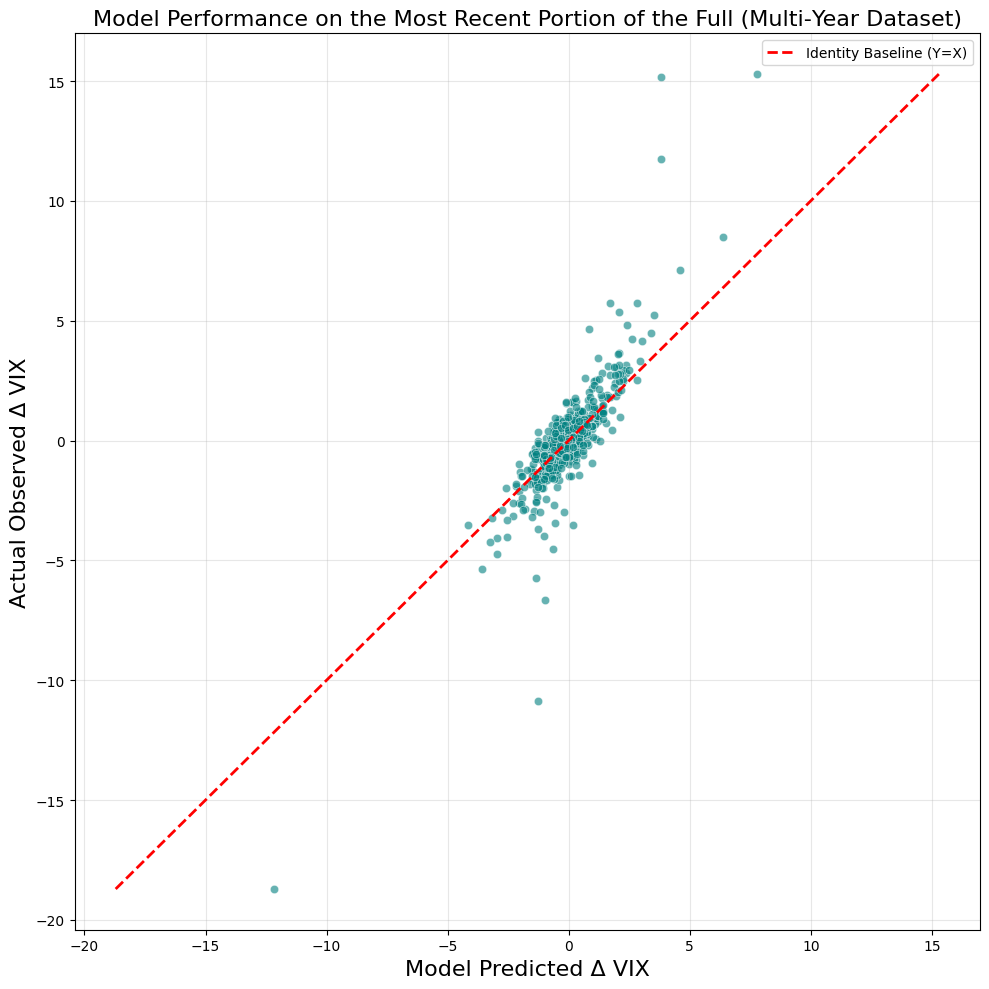

In [10]:
# GRAPH 3: PREDICTED VS. ACTUAL SCATTER PLOT
plt.figure(figsize=(10, 10))
sns.scatterplot(data=test_df, x='Predicted_VIX_Delta', y='VIX_Delta', color='teal', alpha=0.6)

# Overlay perfect fit reference baseline line
min_val = min(test_df['VIX_Delta'].min(), test_df['Predicted_VIX_Delta'].min())
max_val = max(test_df['VIX_Delta'].max(), test_df['Predicted_VIX_Delta'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Identity Baseline (Y=X)')

plt.title('Model Performance on the Most Recent Portion of the Full (Multi‑Year Dataset)', fontsize=16)
plt.xlabel('Model Predicted Δ VIX', fontsize=16)
plt.ylabel('Actual Observed Δ VIX', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('predict_vs_actual.png', dpi=300)
plt.show()

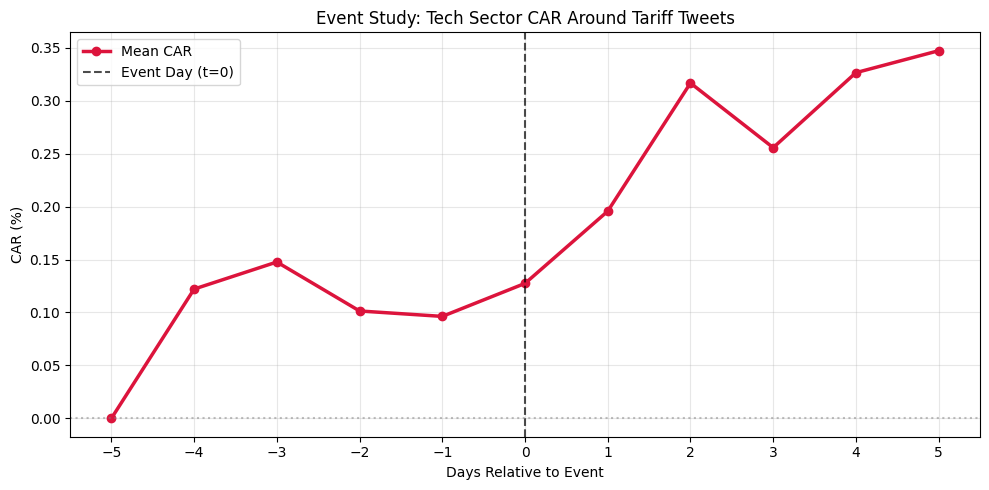

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Define event trigger and window size
ev_dates = df[df['tariff_count'] > 3]['Date'].tolist()
w = 5  
car_list = []

# Ensure strict chronological order
df_ev = df.sort_values('Date').reset_index(drop=True)

for ed in ev_dates:
    idx = df_ev[df_ev['Date'] == ed].index[0]
    
    # Extract window data and compute cumulative abnormal return
    w_alpha = df_ev.loc[idx-w:idx+w, 'Tech_Alpha'].values
    car = np.cumsum(w_alpha) - w_alpha[0]
    car_list.append(car)

# Compute mean CAR and plot
mean_car = np.mean(car_list, axis=0)
plt.figure(figsize=(10, 5))
x_arr = list(range(-w, w + 1))

plt.plot(x_arr, mean_car * 100, color='crimson', marker='o', linewidth=2.5, label='Mean CAR')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.7, label='Event Day (t=0)')
plt.axhline(y=0, color='gray', linestyle=':', alpha=0.5)

plt.title('Event Study: Tech Sector CAR Around Tariff Tweets', fontsize=12)
plt.xlabel('Days Relative to Event', fontsize=10)
plt.ylabel('CAR (%)', fontsize=10)
plt.xticks(x_arr)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('exp_event_study.png', dpi=300)
plt.show()

C:\Users\29768\AppData\Local\Temp\ipykernel_46076\4159828547.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Theme', y='VIX_Chg', data=v_df, palette='muted', inner='quartile')


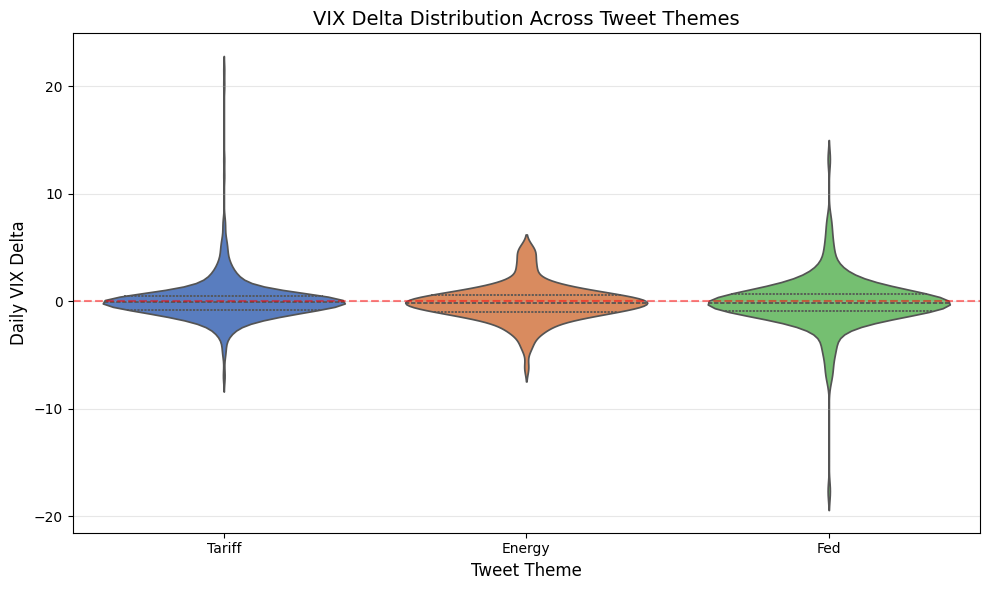

In [12]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

v_list = []

# Melt wide dataframe into long format for visualization
for idx, row in df.iterrows():
    if row['tariff_count'] > 0:
        v_list.append({'Theme': 'Tariff', 'VIX_Chg': row['VIX_Delta']})
    if row['fed_count'] > 0:
        v_list.append({'Theme': 'Fed', 'VIX_Chg': row['VIX_Delta']})
    if row['energy_count'] > 0:
        v_list.append({'Theme': 'Energy', 'VIX_Chg': row['VIX_Delta']})

v_df = pd.DataFrame(v_list)

# Plot violin distribution
plt.figure(figsize=(10, 6))
sns.violinplot(x='Theme', y='VIX_Chg', data=v_df, palette='muted', inner='quartile')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.title('VIX Delta Distribution Across Tweet Themes', fontsize=14)
plt.xlabel('Tweet Theme', fontsize=12)
plt.ylabel('Daily VIX Delta', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('exp_theme_violin.png', dpi=300)
plt.show()

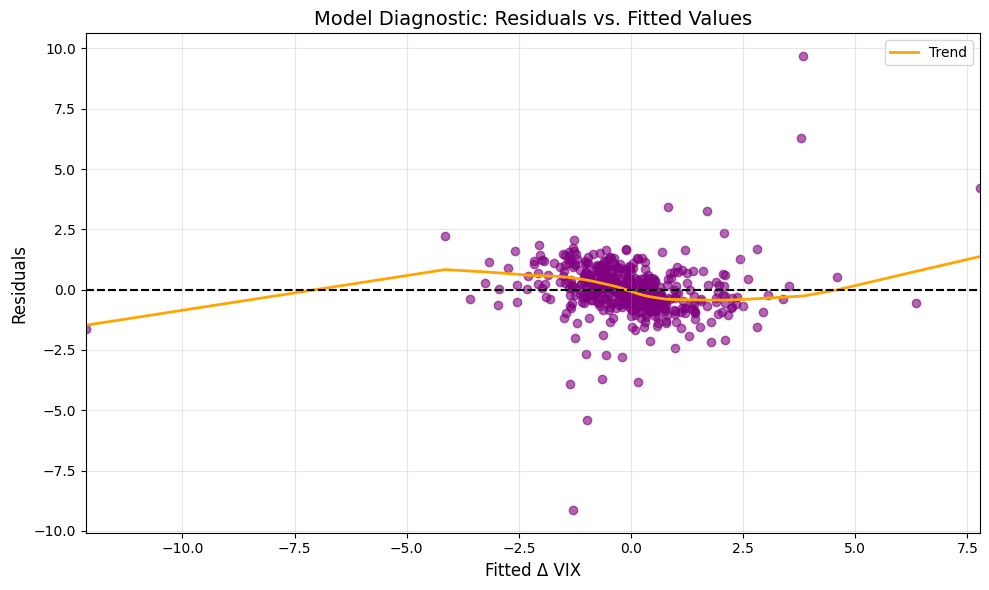

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate residuals from test predictions
test_df['Resid'] = test_df['VIX_Delta'] - test_df['Predicted_VIX_Delta']

plt.figure(figsize=(10, 6))

# Plot residuals against fitted values
sns.residplot(data=test_df, x='Predicted_VIX_Delta', y='Resid', 
              lowess=True, 
              scatter_kws={'alpha': 0.6, 'color': 'purple'},
              line_kws={'color': 'orange', 'linewidth': 2, 'label': 'Trend'})

plt.axhline(y=0, color='black', linestyle='--')
plt.title('Model Diagnostic: Residuals vs. Fitted Values', fontsize=14)
plt.xlabel('Fitted Δ VIX', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('exp_residuals.png', dpi=300)
plt.show()

In [14]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Copy and create volume quantiles
df_q = df.copy()
df_q['Vol_Bin'] = pd.qcut(df_q['tweet_volume'], q=4, labels=['Low', 'Medium', 'High', 'Extreme'])
df_q['Abs_VIX_Dev'] = df_q['VIX_Delta'].abs()

# Plot boxplot for conditional volatility
plt.figure(figsize=(9, 6))
sns.boxplot(x='Vol_Bin', y='Abs_VIX_Dev', data=df_q, palette='Purples', showfliers=False)

plt.title('Conditional Market Volatility by Tweet Volume Quantiles', fontsize=12)
plt.xlabel('Tweet Volume Quantile', fontsize=10)
plt.ylabel('Absolute Δ VIX (Market Reaction)', fontsize=10)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('exp_vol_quantile.png', dpi=300)
plt.show()

ValueError: Bin edges must be unique: Index([0.0, 0.0, 0.0, 11.0, 112.0], dtype='float64', name='tweet_volume').
You can drop duplicate edges by setting the 'duplicates' kwarg

In [ ]:
import matplotlib.pyplot as plt

# Sort test dataset by chronological order
df_ts = test_df.sort_values('Date').reset_index(drop=True)
df_ts['Abs_Err'] = (df_ts['VIX_Delta'] - df_ts['Predicted_VIX_Delta']).abs()

# Plot dual-axis timeline for tracking error and VIX level
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.plot(df_ts['Date'], df_ts['Abs_Err'], color='darkorange', alpha=0.7, label='Absolute Prediction Error')
ax2.plot(df_ts['Date'], df_ts['VIX'], color='navy', alpha=0.4, linestyle='--', label='VIX Level')

ax1.set_title('Model Prediction Error Timeline vs. Market Volatility Context', fontsize=12)
ax1.set_xlabel('Date', fontsize=10)
ax1.set_ylabel('Absolute Error (|Actual - Predicted|)', color='darkorange', fontsize=10)
ax2.set_ylabel('VIX Index Level', color='navy', fontsize=10)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('exp_error_timeline.png', dpi=300)
plt.show()